In [119]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import scipy.io
import time
from scipy.io import loadmat

In [120]:
class ESN(object):

    def __init__(self, inputSize, reservoir_size, topology='full', spectral_radius=0.9, sparsity=0.1):
        """
        Initialize weight and bias between input layer and hidden layer
        Parameters:
        inputSize: int
            The number of input layer dimensions or features in the training data
        outputSize: int
            The number of output layer dimensions
        hiddenSize: int
            The number of hidden layer dimensions
        """

        self.inputSize = inputSize
       #self.outputSize = outputSize
        #self.hiddenSize = hiddenSize
        self.reservoir_size = reservoir_size
        self.spectral_radius = spectral_radius

        # Initialize random weight with range [-0.5, 0.5]
        self.W_in = np.random.uniform(-0.5, 0.5, (self.reservoir_size, self.inputSize))

        # Initialize random bias with range [0, 1]
        self.bias = np.random.uniform(0, 1, (1, self.reservoir_size))

        # Initialize reservoir vbaed on selected configuration topology
        if topology == 'full':
            self.W_res = self._initialize_full(sparsity)
        elif topology == 'ring':
            self.W_res = self._initialize_ring()
        else:
            raise ValueError("Invalid topology. Choose 'full' or 'ring'.")

        # Scale the reservoir to ensure the Echo State Propertyy
        self._scale_spectral_radius()

        # Reservoir weights
        #self.W_res = np.random.rand(reservoir_size, reservoir_size) - 0.5
        #self.W_res *= spectral_radius / \
        #    np.max(np.abs(np.linalg.eigvals(self.W_res)))

        # Output weights (to be trained)
        self.W_out = None

        self.H = 0


    # def sigmoid(self, x):
    #     """
    #     Sigmoid activation function

    #     Parameters:
    #     x: array-like or matrix
    #         The value that the activation output will look for
    #     Returns:
    #         The results of activation using sigmoid function
    #     """
    #     return 1 / (1 + np.exp(-1 * x))

    def _initialize_full(self, sparsity):
        """Generates a fully/densely populated random reservoir matrix."""
        W_res = np.random.uniform(-0.5, 0.5, (self.reservoir_size, self.reservoir_size))
        # Apply standard Erdős-Rényi sparsity mask if needed
        mask = np.random.rand(*W_res.shape) > sparsity
        W_res[mask] = 0.0
        return W_res

    def _initialize_ring(self):
        """Generates a strict simple ring topology reservoir matrix."""
        W_res = np.zeros((self.reservoir_size, self.reservoir_size))
        # Connect neuron i to neuron i+1
        for i in range(self.reservoir_size - 1):
            W_res[i + 1, i] = np.random.uniform(-0.5, 0.5)
        # Close the loop (connect last neuron back to the first)
        W_res[0, self.reservoir_size - 1] = np.random.uniform(-0.5, 0.5)
        return W_res

    def _scale_spectral_radius(self):
        """Scales the matrix to match the target spectral radius."""
        eigenvalues = np.linalg.eigvals(self.W_res)
        max_eigenval = np.max(np.abs(eigenvalues))
        if max_eigenval > 0:
            self.W_res = self.W_res * (self.spectral_radius / max_eigenval)



    def predict(self, X):
        """
        Predict the results of the training process using test data
        Parameters:
        X: array-like or matrix
            Test data that will be used to determine output using ELM
        Returns:
            Predicted results or outputs from test data
        """
        #X = np.matrix(X)

        reservoir_states = self.run_reservoir(X)

        # y = np.dot(self.sigmoid(np.dot(X, self.weight.T) + self.bias), self.beta)
        y = np.dot(reservoir_states, self.W_out)

        return y

    def run_reservoir(self, X):
        # Iniatialize reservoir states
        reservoir_states = np.zeros((len(X), self.reservoir_size))

        # Run the reservoir
        for t in range(1, len(X)):
            reservoir_states[t, :] = np.tanh(
                np.dot(
                    self.W_res, reservoir_states[t-1, :]) + np.dot(self.W_in, X[t])
            )

        return reservoir_states

    def train(self, X, y):
        """
        Extreme Learning Machine training process
        Parameters:
        X: array-like or matrix
            Training data that contains the value of each feature
        y: array-like or matrix
            Training data that contains the value of the target (class)
        Returns:
            The results of the training process
        """

        #X = np.matrix(X)
        #y = np.matrix(y)

        reservoir_states = self.run_reservoir(X)

        #-----------------------------------------------------------------------
        # For use of orthogonal approx method
        # # Calculate hidden layer output matrix (Hinit)
        H = np.tanh(np.dot(X, self.W_in.T) + self.bias)

        # # Sigmoid activation function
        # H_2 = self.sigmoid(self.H)    # For use with MGS
        # self.H = self.sigmoid(self.H)

        # # Calculate the Moore-Penrose pseudoinverse matriks
         #H_moore_penrose = np.dot(np.linalg.inv(np.dot(self.H.T, self.H)), self.H.T)

        # # Calculate the output weight matrix beta
        # self.beta = np.dot(H_moore_penrose, y)

        # ######### Modified Gram Schmidt Process (MGS)
        # Calculate output weigths using another pseudo-inverse construccion method

        m, n = H.shape
        Q = np.zeros((m, n))
        R = np.zeros((n, n))
        V = H.astype(np.float64).copy()  # Work on a copy to avoid modifying input

        for i in range(n):
            R[i, i] = np.linalg.norm(V[:, i])
            if np.isclose(R[i, i], 0):
                raise ValueError("Matrix is rank deficient.")

            Q[:, i] = V[:, i] / R[i, i]

        for j in range(i + 1, n):
            # Key difference: project the UPDATED vectors (MGS)
            # instead of the original ones (CGS)
            R[i, j] = np.dot(Q[:, i], V[:, j])
            V[:, j] = V[:, j] - R[i, j] * Q[:, i]

        # return Q, R

        # Train the output weights using pseudo-inverse
        #self.W_out = np.dot(np.linalg.pinv(reservoir_states), y)
        self.W_out = np.dot(np.dot(np.linalg.pinv(R),Q.T), y)



        # return np.dot(self.H, self.beta_2)
    # Modied Gram Schmidt for approximating the inverse matrix

In [121]:
####################################################################################
# Data from the Lorenz chaotic system
# Full topology

# New data from Lorenz system
mat_data = scipy.io.loadmat('Lorenz3D.mat')
# Access a specific variable by name
data = mat_data['Lorenz3D']

mat_data2 = scipy.io.loadmat('LE_lorenz.mat')
# Access a specific variable by name
labels = mat_data2['LE_lorenz']

# Create an Echo State Network
reservoir_size = 50

# Create instance of ELM object with 10 hidden neuron
esn = ESN(data.shape[1], reservoir_size, topology='full')     # Number of features, _, Number of neurons

# Train test split 80:20
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2)

# Train data
esn.train(X_train,y_train.reshape(-1,1))

# Make prediction from training process
y_pred = esn.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

print('Accuracy: ', accuracy_score(y_test, y_pred))
# print(np.shape(data))

Accuracy:  0.763


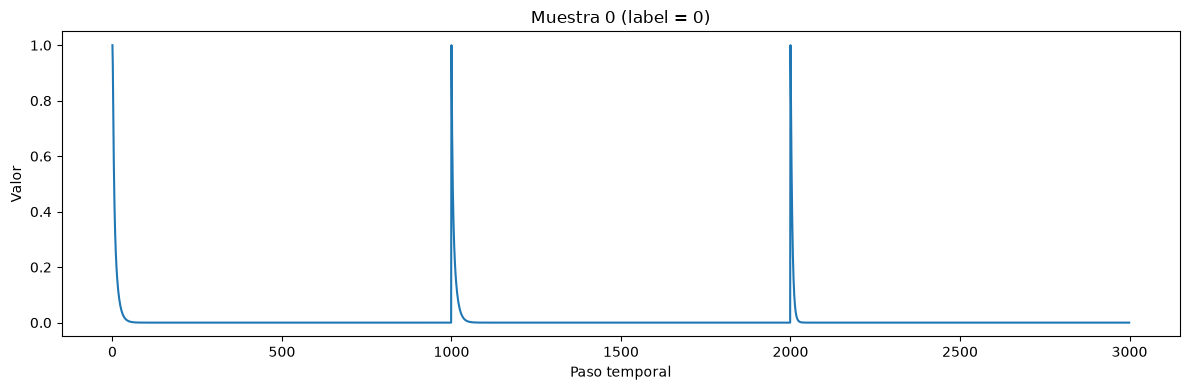

In [122]:
import matplotlib.pyplot as plt

# Grafica una sola muestra (fila) de data para ver si es una serie temporal
idx = 0  # indice de la muestra a graficar
muestra = data[idx]

plt.figure(figsize=(12, 4))
plt.plot(muestra)
plt.title(f'Muestra {idx} (label = {labels[idx][0]})')
plt.xlabel('Paso temporal')
plt.ylabel('Valor')
plt.tight_layout()
plt.show()

Shape original: (5000, 3000)
Shape reducido: (5000, 15)


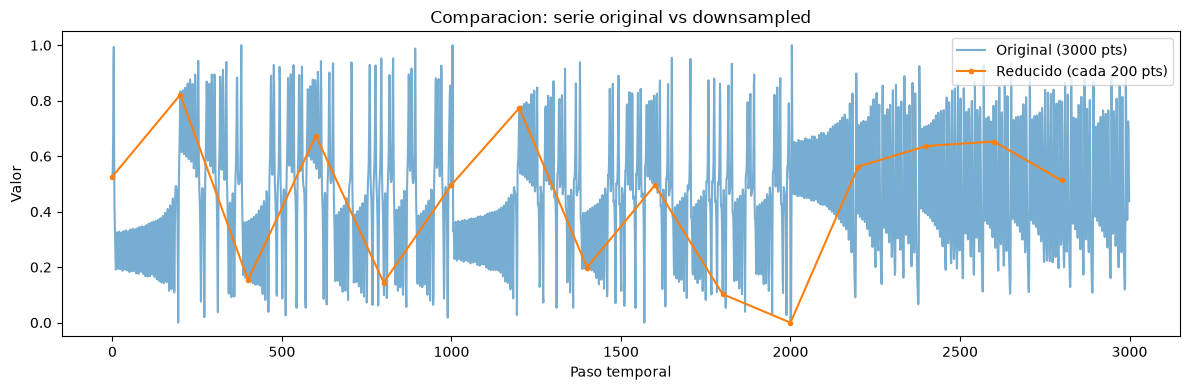

In [134]:
####################################################################################
# Downsampling de features: toma 1 de cada N puntos por muestra
# 3000 features -> 300 features con N=10

N = 200  # factor de downsampling

data_reducido = data[:, ::N]

print(f'Shape original: {data.shape}')
print(f'Shape reducido: {data_reducido.shape}')

# Comparacion visual: muestra original vs reducida
plt.figure(figsize=(12, 4))
plt.plot(data[500], label='Original (3000 pts)', alpha=0.6)
plt.plot(range(0, data.shape[1], N), data_reducido[500], 'o-', label=f'Reducido (cada {N} pts)', markersize=3)
plt.title('Comparacion: serie original vs downsampled')
plt.xlabel('Paso temporal')
plt.ylabel('Valor')
plt.legend()
plt.tight_layout()
plt.show()

In [124]:
####################################################################################
# Entrenar la ESN usando el dataset reducido (downsampled)

esn_reducido = ESN(data_reducido.shape[1], reservoir_size, topology='full')

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(data_reducido, labels, test_size=0.2)

esn_reducido.train(X_train_r, y_train_r.reshape(-1, 1))

y_pred_r = esn_reducido.predict(X_test_r)
y_pred_r = (y_pred_r > 0.5).astype(int)

print(f'Features usadas: {data_reducido.shape[1]} (N={N})')
print('Accuracy (reducido): ', accuracy_score(y_test_r, y_pred_r))

Features usadas: 300 (N=10)
Accuracy (reducido):  0.759


In [130]:
####################################################################################
# Barrido de decimacion N: para cada N se corre M veces la ESN (con distinto
# train/test split cada vez) y se promedia el accuracy.
# La primera prueba es SIN decimacion (N=1, todas las 3000 features),
# luego N=10, 20, ..., 150.
# Se va imprimiendo el resultado de cada N apenas termina, para ver la evolucion.

import pandas as pd

M = 100                    # numero de corridas por cada N
N_values = [1] + list(range(10, 301, 10))   # N = 1 (sin decimar), 10, 20, ..., 150

resultados = []

print(f'Iniciando barrido: {len(N_values)} valores de N, {M} corridas cada uno...\n', flush=True)

for N_val in N_values:
    data_N = data if N_val == 1 else data[:, ::N_val]
    accs = np.zeros(M)

    for m in range(M):
        esn_m = ESN(data_N.shape[1], reservoir_size, topology='full')

        X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
            data_N, labels, test_size=0.2
        )

        esn_m.train(X_train_m, y_train_m.reshape(-1, 1))

        y_pred_m = esn_m.predict(X_test_m)
        y_pred_m = (y_pred_m > 0.5).astype(int)

        accs[m] = accuracy_score(y_test_m, y_pred_m)

    resultados.append({
        'N': N_val,
        'n_features': data_N.shape[1],
        'accuracy_promedio': accs.mean(),
        'accuracy_std': accs.std(),
    })

    etiqueta = 'sin decimar' if N_val == 1 else f'N={N_val}'
    # Se imprime apenas termina cada N, para ver la evolucion en vivo
    print(f'{etiqueta:>12} | features={data_N.shape[1]:>4} | '
          f'accuracy promedio={accs.mean():.4f} +- {accs.std():.4f}', flush=True)

tabla_resultados = pd.DataFrame(resultados)
tabla_resultados

Iniciando barrido: 31 valores de N, 100 corridas cada uno...

 sin decimar | features=3000 | accuracy promedio=0.7693 +- 0.0111
        N=10 | features= 300 | accuracy promedio=0.7703 +- 0.0116
        N=20 | features= 150 | accuracy promedio=0.7705 +- 0.0109
        N=30 | features= 100 | accuracy promedio=0.7704 +- 0.0106
        N=40 | features=  75 | accuracy promedio=0.7697 +- 0.0102
        N=50 | features=  60 | accuracy promedio=0.7685 +- 0.0111
        N=60 | features=  50 | accuracy promedio=0.7699 +- 0.0129
        N=70 | features=  43 | accuracy promedio=0.7690 +- 0.0130
        N=80 | features=  38 | accuracy promedio=0.7691 +- 0.0111
        N=90 | features=  34 | accuracy promedio=0.7708 +- 0.0100
       N=100 | features=  30 | accuracy promedio=0.7693 +- 0.0115
       N=110 | features=  28 | accuracy promedio=0.7685 +- 0.0110
       N=120 | features=  25 | accuracy promedio=0.7679 +- 0.0120
       N=130 | features=  24 | accuracy promedio=0.7690 +- 0.0143
       N=140 |

,N,n_features,accuracy_promedio,accuracy_std
0,1,3000,0.76926,0.011104
1,10,300,0.77030,0.011560
2,20,150,0.77047,0.010877
3,30,100,0.77039,0.010635
4,40,75,0.76973,0.010161
5,50,60,0.76855,0.011081
6,60,50,0.76987,0.012950
7,70,43,0.76896,0.012996
8,80,38,0.76911,0.011090
9,90,34,0.77081,0.009969


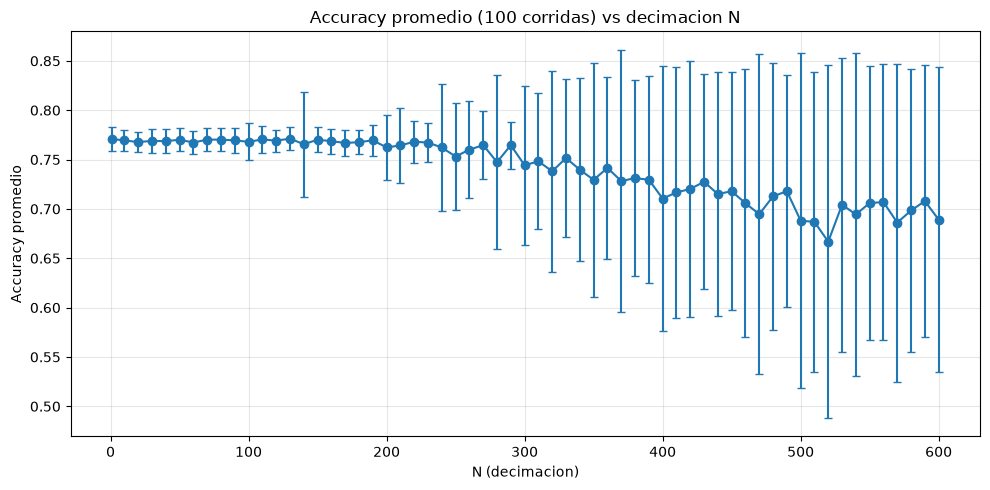

In [128]:
####################################################################################
# Grafica del accuracy promedio en funcion de N

plt.figure(figsize=(10, 5))
plt.errorbar(
    tabla_resultados['N'],
    tabla_resultados['accuracy_promedio'],
    yerr=tabla_resultados['accuracy_std'],
    marker='o', capsize=3
)
plt.title(f'Accuracy promedio ({M} corridas) vs decimacion N')
plt.xlabel('N (decimacion)')
plt.ylabel('Accuracy promedio')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()